## Holiday Season Crashes?

![](data/sign.webp)

When I was thinking about what to explore for this assignment, I thought back to being home during breaks. My parents would constantly remind me, “don’t drink and drive,” or “be especially careful tonight, lots of accidents happen during the holidays.” They weren’t the only ones saying it either. Even in my small town there would be police everywhere, temporary billboards warning about DUIs, and constant reminders about holiday driving.

Those warnings always made the holiday season feel like a particularly dangerous time to be on the road. For this week’s exploration, I wanted to see whether that perception actually shows up in the data. Do crashes really increase during the holiday season, or do all of those warnings and extra police patrols actually help prevent accidents?

That question became the starting point for my analysis. My initial goal was simple: find out whether crashes increase during the holiday season. As I started digging into the dataset, however, the data ended up taking me in a slightly different direction.

In [27]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

In [ ]:
crash_data = pd.read_csv('data/PDOT_crash_data_2005_2024.csv', low_memory=False)

In [7]:
data_dictionary = pd.read_csv('data/data_dictionary.csv')

### Monthly Data

Immediately after filtering the data by month, the number of crashes in November and December appeared to exceed those in other months. To be sure, I plotted the data and highlighted the final two months of the year. Lo and behold, crashes really were more common during those last months.

In [9]:
crashes_by_month = crash_data['CRASH_MONTH'].value_counts().sort_index()

crashes_by_month

CRASH_MONTH
1     58378
2     51922
3     54058
4     53429
5     60051
6     57348
7     54447
8     55110
9     56381
10    65006
11    60991
12    63948
Name: count, dtype: int64

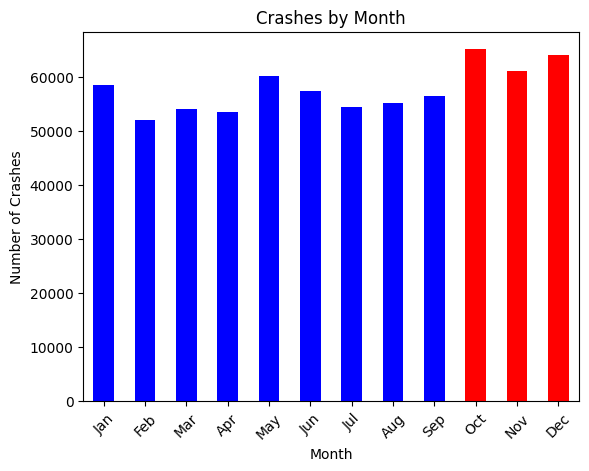

In [10]:
colors = ['blue'] * 12
colors[9] = 'red'   
colors[10] = 'red'  
colors[11] = 'red'  

crashes_by_month.plot(kind='bar', color=colors)

plt.title("Crashes by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crashes")

plt.xticks(
    range(12),
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation=45
)

plt.show()

To take the investigation further, I wanted to look at the number of crashes by hour of the day. Many crashes involving drunk driving, or driving under any form of influence, tend to occur later at night. I planned to cross-reference crashes by hour with November and December, expecting to see the highest number of late-night crashes at the end of the year.

In [11]:
crash_data['HOUR_OF_DAY'].value_counts().sort_index()

HOUR_OF_DAY
0.0      684
1.0      636
2.0      657
3.0      436
4.0      349
5.0      439
6.0      830
7.0     1427
8.0     1398
9.0     1203
10.0    1124
11.0    1273
12.0    1358
13.0    1391
14.0    1530
15.0    1848
16.0    1903
17.0    2004
18.0    1658
19.0    1207
20.0    1032
21.0     948
22.0     861
23.0     766
99.0     486
Name: count, dtype: int64

In [12]:
late_night = crash_data[crash_data['HOUR_OF_DAY'].isin([22,23,0,1,2,3])]

holiday_late_night = crash_data[
    (crash_data['CRASH_MONTH'].isin([11,12])) &
    (crash_data['HOUR_OF_DAY'].isin([22,23,0,1,2,3]))
]

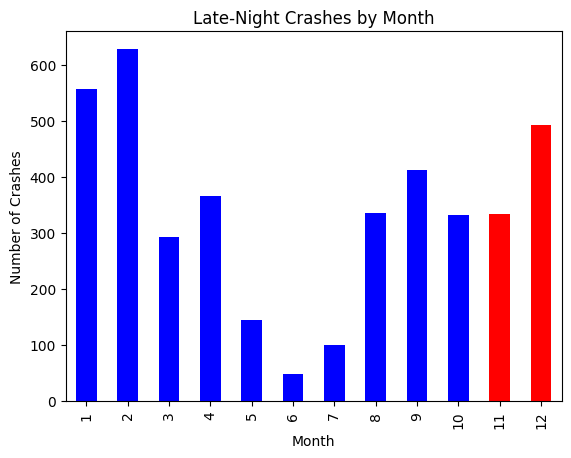

In [13]:
counts = late_night['CRASH_MONTH'].value_counts().sort_index()

colors = ['blue'] * 12
colors[10] = 'red'
colors[11] = 'red'

counts.plot(kind='bar', color=colors)

plt.title("Late-Night Crashes by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crashes")

plt.show()

To my surprise, I was mistaken. November and December were not only not the months with the highest number of late-night crashes, they weren’t even second. February, by a large margin, had the highest number. That result made me curious, so I decided to dig further.

I wondered whether the number of crashes in February represented a real pattern or whether it was driven by a few unusual outlier years. When I plotted late-night February crashes by year, I found that a handful of years were indeed responsible for the spike, while other years had almost none. Was it because of Valentine’s Day? Maybe because the Eagles won the Super Bowl in 2018?

In [25]:
late_night[late_night['CRASH_MONTH'] == 2]['CRASH_YEAR'].value_counts().sort_index()

CRASH_YEAR
2005    140
2007      1
2008      1
2010      5
2011     48
2013     86
2018     63
2020      2
2021     11
2022    139
2023    132
Name: count, dtype: int64

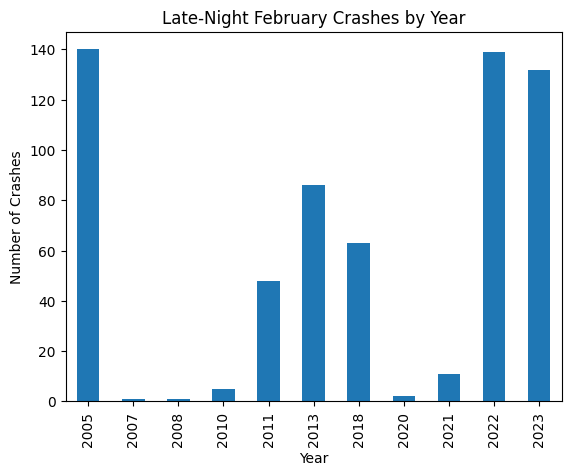

In [26]:
late_night[late_night['CRASH_MONTH'] == 2]['CRASH_YEAR'].value_counts().sort_index().plot(kind='bar')

plt.title("Late-Night February Crashes by Year")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.show()

I explored the crashes by day of week, and found that Saturday and Sunday were the days of the week with highest crash numbers- unsurprising because people are out later and often drinking on those days, though I'm surprised Friday isn't up higher. Second, the number of crashes does seem to concentrate around the hours of 10pm and midnight.

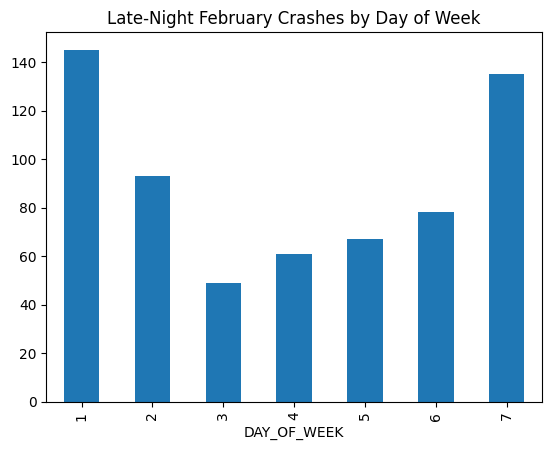

In [18]:
late_night[late_night['CRASH_MONTH'] == 2]['DAY_OF_WEEK'].value_counts().sort_index().plot(kind='bar')

plt.title("Late-Night February Crashes by Day of Week")

plt.show()

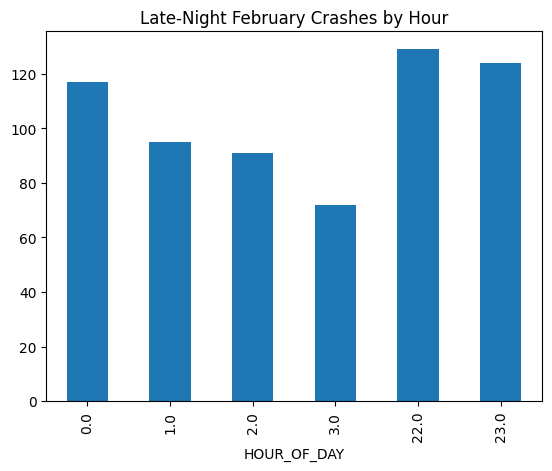

In [19]:
late_night[late_night['CRASH_MONTH'] == 2]['HOUR_OF_DAY'].value_counts().sort_index().plot(kind='bar')

plt.title("Late-Night February Crashes by Hour")

plt.show()

For some reason, the earlier plot had not included every year from 2005–2024. I decided to plot the data again to make sure the missing years didn’t contain anything interesting. Even after correcting this, the pattern still puzzled me. Why were some years so bad while others had almost no crashes at all?

My next thought was that the explanation might have something to do with weather. Poor weather conditions often lead to more accidents, especially during winter months. Expecting to see snow or heavy winter storms behind the spikes, I plotted crashes by weather condition. Surprisingly, snow wasn’t the main factor. Instead, rain appeared to be the real culprit.

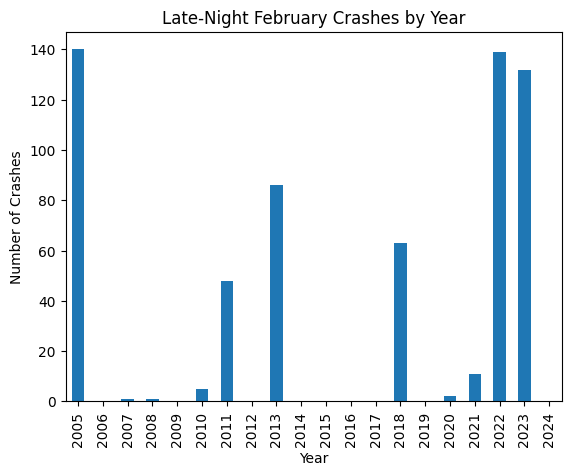

In [20]:
feb_counts = late_night[late_night['CRASH_MONTH'] == 2]['CRASH_YEAR'].value_counts().sort_index()

years = sorted(crash_data['CRASH_YEAR'].unique())

feb_counts = feb_counts.reindex(years, fill_value=0)

feb_counts.plot(kind='bar')

plt.title("Late-Night February Crashes by Year")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")

plt.show()

In [21]:
crash_data['WEATHER1'].value_counts()

WEATHER1
3.0     31249
7.0      4847
4.0      1801
10.0      792
99.0      232
5.0       175
6.0       102
2.0        78
98.0       73
9.0        31
8.0         8
1.0         1
Name: count, dtype: int64

In [22]:
feb = crash_data[crash_data['CRASH_MONTH'] == 2]

feb['CRASH_YEAR'].value_counts().sort_index()

feb_spike_years = feb[feb['CRASH_YEAR'].isin([2005,2013,2018,2022,2023])]

feb_spike_years['WEATHER1'].value_counts()

WEATHER1
3.0    30
4.0     2
Name: count, dtype: int64

In [23]:
weather_labels = {
    1.0: "Clear",
    2.0: "Cloudy",
    3.0: "Rain",
    4.0: "Snow",
    5.0: "Freezing Rain / Sleet",
    6.0: "Fog",
    7.0: "Severe Crosswinds",
    8.0: "Blowing Snow",
    9.0: "Smoke / Smog",
    10.0: "Other",
    98.0: "Not Reported",
    99.0: "Unknown"
}

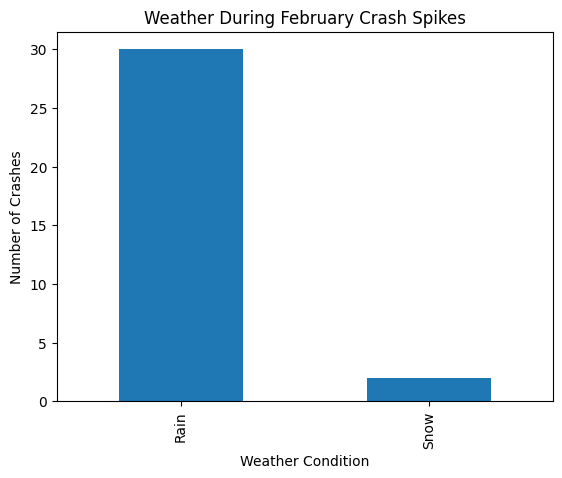

In [24]:
weather_counts = feb_spike_years['WEATHER1'].value_counts()

weather_counts.index = weather_counts.index.map(weather_labels)

weather_counts.plot(kind='bar')

plt.title("Weather During February Crash Spikes")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Crashes")

plt.show()

Going into this exploration, I expected to find that crashes were most common during the holiday season, especially late at night when people are more likely to be drinking. The early plots even seemed to support that idea, with November and December initially appearing to have higher crash numbers. But as I dug deeper and started breaking the data down by hour, month, and year, the story became much less straightforward.

Late-night crashes were not actually highest during the holiday season. Instead, February stood out, and even that pattern turned out to be driven largely by a handful of specific years rather than a consistent trend. Looking more closely at those spike years suggested that weather, particularly rain, may play a larger role in late-night crashes than I originally expected.

In the end, the data didn’t fully confirm the story I had in mind when I started. Holiday driving warnings may still be important, but at least in this dataset, late-night crash patterns seem to be influenced by a mix of factors including specific years, weather conditions, and weekend behavior.